I will implement here feature extraction using PCA (Principal Component Analysis) using python from scratch

In [81]:
import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from itertools import combinations
from sklearn.base import clone
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
import matplotlib.patheffects as PathEffects

In [3]:
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                'machine-learning-databases/wine/wine.data',header=None)
print(df_wine)
df_wine.isnull().sum()


     0      1     2     3     4    5     6     7     8     9      10    11  \
0     1  14.23  1.71  2.43  15.6  127  2.80  3.06  0.28  2.29   5.64  1.04   
1     1  13.20  1.78  2.14  11.2  100  2.65  2.76  0.26  1.28   4.38  1.05   
2     1  13.16  2.36  2.67  18.6  101  2.80  3.24  0.30  2.81   5.68  1.03   
3     1  14.37  1.95  2.50  16.8  113  3.85  3.49  0.24  2.18   7.80  0.86   
4     1  13.24  2.59  2.87  21.0  118  2.80  2.69  0.39  1.82   4.32  1.04   
..   ..    ...   ...   ...   ...  ...   ...   ...   ...   ...    ...   ...   
173   3  13.71  5.65  2.45  20.5   95  1.68  0.61  0.52  1.06   7.70  0.64   
174   3  13.40  3.91  2.48  23.0  102  1.80  0.75  0.43  1.41   7.30  0.70   
175   3  13.27  4.28  2.26  20.0  120  1.59  0.69  0.43  1.35  10.20  0.59   
176   3  13.17  2.59  2.37  20.0  120  1.65  0.68  0.53  1.46   9.30  0.60   
177   3  14.13  4.10  2.74  24.5   96  2.05  0.76  0.56  1.35   9.20  0.61   

       12    13  
0    3.92  1065  
1    3.40  1050  
2    3.17

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64

In [4]:
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y, random_state=0)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [5]:
cov_matrix = np.cov(X_train_std.T)
cov_matrix_test = np.cov(X_test_std.T)
eigen_val, eigen_vec = np.linalg.eig(cov_matrix)
print(eigen_val)
eigen_val_test, eigen_vec_test = np.linalg.eig(cov_matrix_test)
print(eigen_val_test)

[4.84274532 2.41602459 1.54845825 0.96120438 0.84166161 0.6620634
 0.51828472 0.34650377 0.3131368  0.10754642 0.21357215 0.15362835
 0.1808613 ]
[4.60875701 2.90204017 1.31306798 0.93788381 0.7853038  0.06834849
 0.11104083 0.12866858 0.2066364  0.26340181 0.3525347  0.53181959
 0.5036732 ]


In [6]:
eigen_pairs = [(np.abs(eigen_val[i]), eigen_vec[:, i]) for i in range(len(eigen_val))]
eigen_pairs.sort(key=lambda k: k[0], reverse=True)
print(eigen_pairs[0:3])
eigen_pairs_test = [(np.abs(eigen_val_test[i]), eigen_vec_test[:, i]) for i in range(len(eigen_val_test))]
eigen_pairs_test.sort(key=lambda k: k[0], reverse=True)
print(eigen_pairs_test[0:3])

[(np.float64(4.842745315655894), array([-0.13724218,  0.24724326, -0.02545159,  0.20694508, -0.15436582,
       -0.39376952, -0.41735106,  0.30572896, -0.30668347,  0.07554066,
       -0.32613263, -0.36861022, -0.29669651])), (np.float64(2.416024587035226), array([ 0.50303478,  0.16487119,  0.24456476, -0.11352904,  0.28974518,
        0.05080104, -0.02287338,  0.09048885,  0.00835233,  0.54977581,
       -0.20716433, -0.24902536,  0.38022942])), (np.float64(1.5484582488203504), array([-0.13774873,  0.09615039,  0.67777567,  0.62504055,  0.19613548,
        0.14031057,  0.11705386,  0.13121778,  0.0304309 , -0.07992997,
        0.05305915,  0.13239103, -0.07065022]))]
[(np.float64(4.608757010849945), array([-0.12999701,  0.2045815 ,  0.08570227,  0.31941304, -0.10668011,
       -0.41039418, -0.39670979,  0.31182429, -0.27102652,  0.141004  ,
       -0.27880867, -0.42829415, -0.2072508 ])), (np.float64(2.9020401692829183), array([ 0.43638363,  0.24534465,  0.37095787,  0.06403434,  0.33

In [7]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis], eigen_pairs[1][1][:, np.newaxis]))
print(w)
w_test = np.hstack((eigen_pairs_test[0][1][:, np.newaxis], eigen_pairs[1][1][:, np.newaxis]))
print(w_test)

[[-0.13724218  0.50303478]
 [ 0.24724326  0.16487119]
 [-0.02545159  0.24456476]
 [ 0.20694508 -0.11352904]
 [-0.15436582  0.28974518]
 [-0.39376952  0.05080104]
 [-0.41735106 -0.02287338]
 [ 0.30572896  0.09048885]
 [-0.30668347  0.00835233]
 [ 0.07554066  0.54977581]
 [-0.32613263 -0.20716433]
 [-0.36861022 -0.24902536]
 [-0.29669651  0.38022942]]
[[-0.12999701  0.50303478]
 [ 0.2045815   0.16487119]
 [ 0.08570227  0.24456476]
 [ 0.31941304 -0.11352904]
 [-0.10668011  0.28974518]
 [-0.41039418  0.05080104]
 [-0.39670979 -0.02287338]
 [ 0.31182429  0.09048885]
 [-0.27102652  0.00835233]
 [ 0.141004    0.54977581]
 [-0.27880867 -0.20716433]
 [-0.42829415 -0.24902536]
 [-0.2072508   0.38022942]]


In [8]:
X_train_pca = X_train_std.dot(w)
print(X_train_pca[0:5])
X_test_pca = X_test_std.dot(w_test)
print(X_test_pca[0:5])

[[ 2.38299011  0.45458499]
 [-1.96578183  1.65376939]
 [-2.53907598  1.02909066]
 [-1.43010776  0.6024011 ]
 [ 3.14147227  0.66214979]]
[[-1.91281964  1.86180585]
 [ 0.55558111 -1.66133869]
 [-2.38729603  1.14767406]
 [-2.47173581 -0.1557202 ]
 [-2.35333511 -1.44364994]]


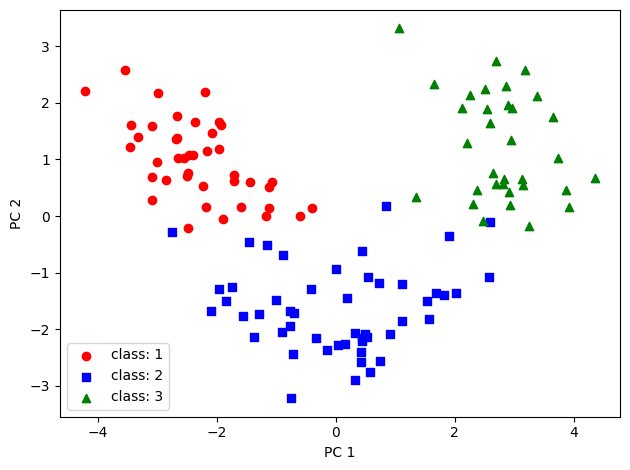

In [9]:
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']
for i, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == i, 0],
                X_train_pca[y_train ==i, 1],
                c=c, marker=m, label=f'class: {i}')
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [10]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
# setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
        y=X[y == cl, 1],
        alpha=0.8,
        c=colors[idx],
        marker=markers[idx],
        label=f'Class {cl}',
        edgecolor='black')

d:\Projects\Learning-ML-Hands-On\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


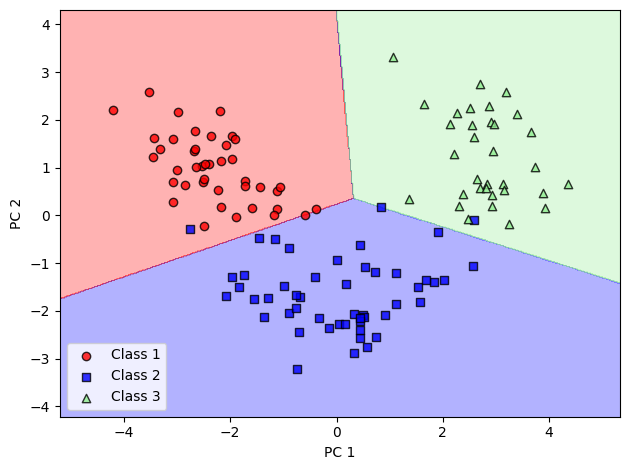

In [11]:
lr = LogisticRegression(multi_class='ovr', random_state=1, solver='lbfgs')
lr.fit(X_train_pca, y_train)
plot_decision_regions(X_train_pca, y_train, classifier=lr)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

d:\Projects\Learning-ML-Hands-On\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


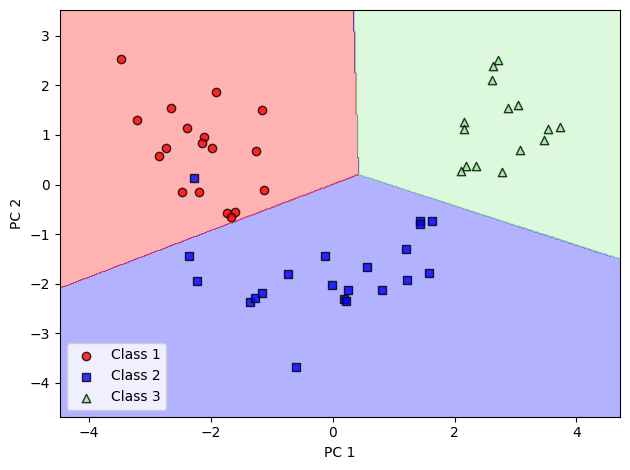

In [12]:
lr = LogisticRegression(multi_class='ovr', random_state=1, solver='lbfgs')
lr.fit(X_test_pca, y_test)
plot_decision_regions(X_test_pca, y_test, classifier=lr)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [13]:
loadings = eigen_vec * np.sqrt(eigen_val)
loadings_test = eigen_vec_test * np.sqrt(eigen_val_test)
print(loadings[:, 0:1])
print(loadings_test[:, 0:1])

[[-0.3020184 ]
 [ 0.54408942]
 [-0.05600938]
 [ 0.45540829]
 [-0.33970111]
 [-0.8665386 ]
 [-0.9184327 ]
 [ 0.67279444]
 [-0.67489496]
 [ 0.16623657]
 [-0.71769524]
 [-0.81117245]
 [-0.65291742]]
[[-0.2790778 ]
 [ 0.43919588]
 [ 0.18398577]
 [ 0.68571642]
 [-0.22902104]
 [-0.88103487]
 [-0.8516572 ]
 [ 0.66942487]
 [-0.58184015]
 [ 0.30270761]
 [-0.59854689]
 [-0.91946255]
 [-0.44492635]]


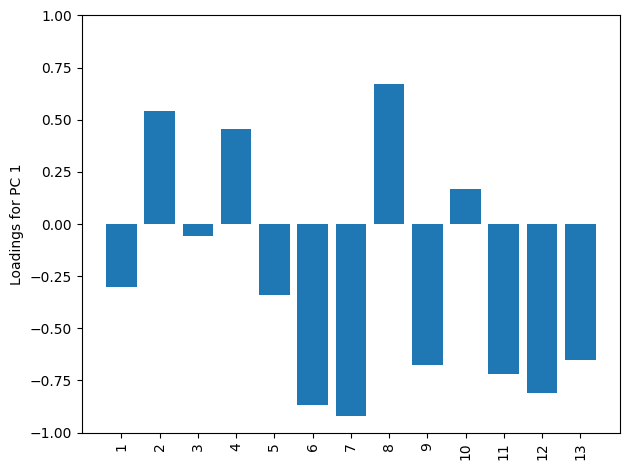

In [14]:
fig, ax = plt.subplots()
ax.bar(range(13), loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
plt.ylim([-1,1])
plt.tight_layout()
plt.show()


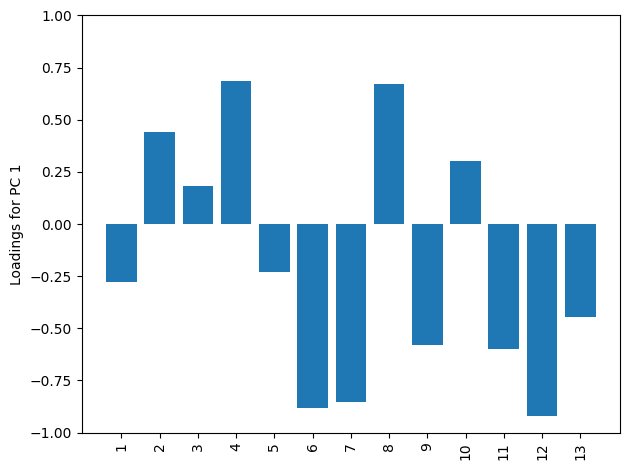

In [15]:
fig, ax = plt.subplots()
ax.bar(range(13), loadings_test[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
plt.ylim([-1,1])
plt.tight_layout()
plt.show()

Now, I will apply dimentionality reduction using LDA (Linear Discriminant Analysis)

In [20]:
np.set_printoptions(precision=5)
mean_vcs = []
for label in range(1, 4):
    mean_vcs.append(np.mean(X_train_std[y_train == label], axis=0))

print(mean_vcs)

[array([ 0.90658, -0.34973,  0.3201 , -0.71891,  0.50559,  0.8807 ,
        0.95895, -0.55161,  0.54159,  0.23383,  0.58971,  0.65631,
        1.20749]), array([-0.87488, -0.2848 , -0.37347,  0.31571, -0.3848 , -0.04333,
        0.06345, -0.09461,  0.07035, -0.8286 ,  0.31437,  0.36084,
       -0.72529]), array([ 0.19922,  0.86603,  0.16816,  0.41484, -0.04512, -1.02856,
       -1.28756,  0.82868, -0.77948,  0.96494, -1.20899, -1.36215,
       -0.4013 ])]


In [28]:
d = 13
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vcs):
    class_scatter = np.zeros((d, d))
    for row in X_train_std[y_train == label]:
        row, mv = row.reshape(d, 1), mv.reshape(1, d)
        class_scatter += (row - mv).dot((row - mv).T)
    S_W += class_scatter
print(f"{S_W.shape[0]} x {S_W.shape[1]}")


13 x 13


In [66]:
print('Class label distribution:',
np.bincount(y_train)[1:])

Class label distribution: [41 50 33]


In [ ]:
mean_overall = np.mean(X_train_std, axis=0)
mean_overall = mean_overall.reshape(d, 1)

d = 13
S_B = np.zeros((d, d))
for i, mean_i in enumerate(mean_vcs):
    n = X_train_std[y_train == i + 1, :].shape[0]
    mean_i = mean_i.reshape(d, 1)
    S_B += n * (mean_i - mean_overall).dot((mean_i - mean_overall).T)

print(f"{S_B.shape[0]} x {S_B.shape[1]}")

13 x 13


In [67]:
eigen_val, eigen_vec = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))
eigen_pairs = [(np.abs(eigen_val[i]), eigen_vec[:,i]) for i in range(len(eigen_vec))]
print(eigen_pairs[0][0:2])

(np.float64(0.07896657471327179), array([-0.29786+0.j,  0.08549+0.j, -0.17796+0.j,  0.30789+0.j,
       -0.00971+0.j,  0.1665 +0.j, -0.53409+0.j, -0.00397+0.j,
        0.03963+0.j,  0.29945+0.j,  0.12403+0.j, -0.22372+0.j,
       -0.55475+0.j]))


In [69]:
eigen_pairs = sorted(eigen_pairs, key=lambda k: k[0], reverse=True)
for eigen_val in eigen_pairs:
    print(eigen_val[0])

0.07896657471327179
0.06307359891627722
6.320611709371321e-17
3.590666026953524e-17
3.0819610979639874e-17
3.0819610979639874e-17
2.223658205094798e-17
1.536170583391412e-17
1.536170583391412e-17
6.3144818186357835e-18
6.3144818186357835e-18
4.727813320574159e-18
4.727813320574159e-18


In [70]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis], eigen_pairs[1][1][:, np.newaxis]))
print(w)

[[-0.29786+0.j -0.34687+0.j]
 [ 0.08549+0.j -0.15202+0.j]
 [-0.17796+0.j -0.36072+0.j]
 [ 0.30789+0.j  0.29156+0.j]
 [-0.00971+0.j -0.02724+0.j]
 [ 0.1665 +0.j -0.01499+0.j]
 [-0.53409+0.j  0.51801+0.j]
 [-0.00397+0.j  0.08282+0.j]
 [ 0.03963+0.j  0.0723 +0.j]
 [ 0.29945+0.j -0.30096+0.j]
 [ 0.12403+0.j  0.29208+0.j]
 [-0.22372+0.j  0.12606+0.j]
 [-0.55475+0.j -0.41022+0.j]]


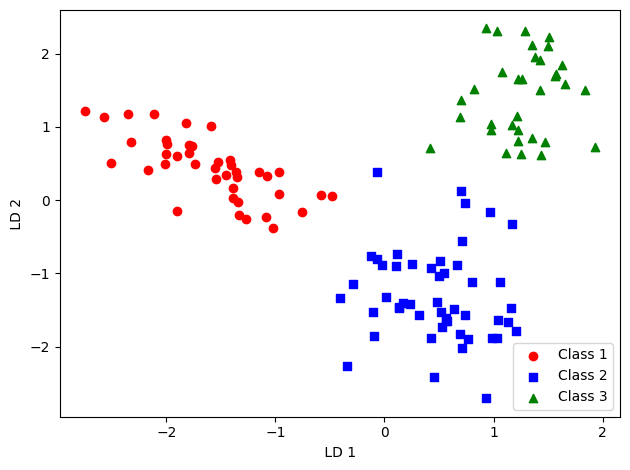

In [72]:
X_train_lda = X_train_std.dot(w)
colors = ['r', 'b', 'g']
marker = ['o', 's', '^']
for i, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_lda[y_train == i, 0], (-1) * X_train_lda[y_train == i, 1], marker=m, c=c, label=f'Class {i}')
plt.xlabel(' LD 1 ')
plt.ylabel(' LD 2 ')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [75]:
digits = load_digits()
digits.data.shape

(1797, 64)

In [94]:
y_digits = digits.target
X_digits = digits.data
tnse = TSNE(n_components=2, init='pca', random_state=123)
X_digits_tnse = tnse.fit_transform(X_digits)
X_digits_tnse


array([[ -2.71072, -53.76646],
       [ 10.15933,  11.76322],
       [-14.05182,  18.68489],
       ...,
       [ -6.0532 ,  10.79109],
       [-20.94168, -15.1647 ],
       [-14.13503,   7.03672]], shape=(1797, 2), dtype=float32)

In [88]:
def plot_projection(x, colors):
    f = plt.figure(figsize=(10, 10))
    ax = plt.subplot(aspect='equal')
    for i in range(10):
        plt.scatter(x[colors == i, 0], x[colors == i, 1])
    
    for i in range(10):
        xtext, ytext = np.median(x[colors == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects([PathEffects.Stroke(linewidth=5, foreground="w"), PathEffects.Normal()])


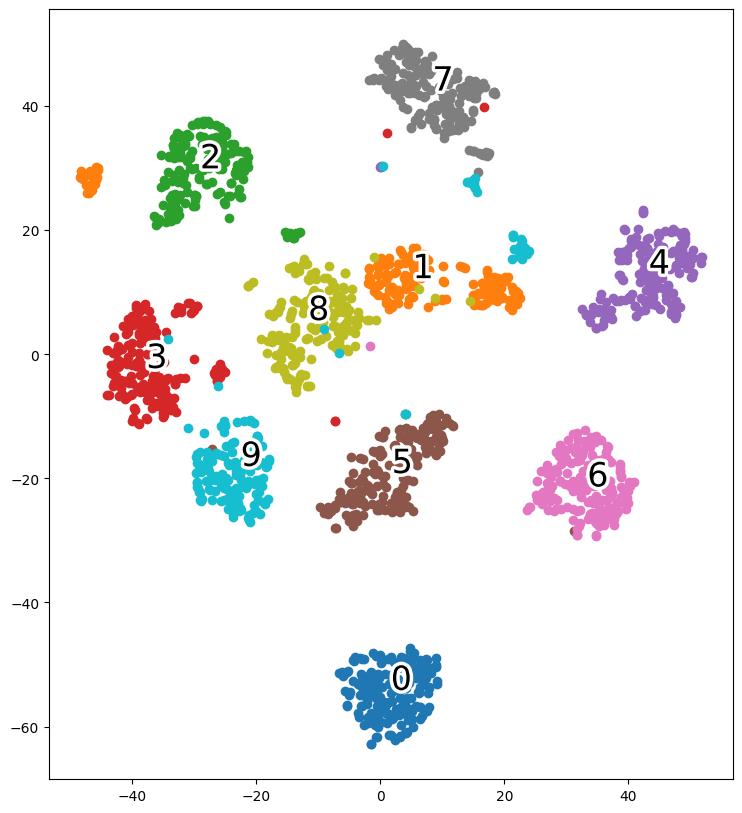

In [95]:
plot_projection(X_digits_tnse, y_digits)
plt.show()